#Model 3: CNN for Swahili News Classification

Prepared by Alain  |  **Model:** `cnn`

One-dimensional CNN over word embeddings (Kim, 2014), trained on the shared splits from `src.data_loading`.

**Experiments in this notebook**

| # | Experiment | Question it answers |
|---|------------|---------------------|
| 1 | Random embeddings, filter sizes 3, 4 and 5 | Baseline CNN that learns local phrases |
| 2 | Pretrained Swahili fastText embeddings | Does prior knowledge of Swahili words help with only ~3,600 articles? (Hypothesis: averaged fastText did badly on Swahili news — Kastanos and Martin, 2021) |
| 3 | Change the maximum article length | How much of each article does the CNN need? (Median is about 270 words) |
| 4 | With and without class weights | Does weighting help the rare classes? |

## 1. Setup

In [1]:
MEMBER = "Alain"
MODEL_NAME = "cnn"

In [2]:
import os
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules

if COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Cloning into 'nlp_language_technologies'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 107 (delta 44), reused 92 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 6.49 MiB | 4.96 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/nlp_language_technologies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.9 MB/s eta 0:00:00
Working directory: /content/nlp_language_technologies


In [3]:
# project dependencies fetching
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from src import config
from src import data_loading
from src import evaluation
from src import plots
from src.experiment_log import log_experiment
from src.reproducibility import FINAL_RUN_SEEDS, set_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load the data

In [7]:
# Loading the train, test, validation data

train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

train_ids = data_loading.labels_to_ids(train["category"])
validation_ids = data_loading.labels_to_ids(validation["category"])
test_ids = data_loading.labels_to_ids(test["category"])

print("Labels in order:", config.LABELS)
print("Sizes:",
      len(train), "for train|",
      len(validation), "for validation|",
      len(test), "for test")

Labels in order: ['kitaifa', 'michezo', 'biashara', 'kimataifa', 'burudani']
Sizes: 3603 for train| 772 for validation| 773 for test


## 3. Build and train the model

### 3a. Tokenizer and vocabulary

**This tokenizer/vocabulary block is shared with `05_bilstm.ipynb`** (the BiLSTM notebook uses exactly the same code) so both models see identical inputs.

The tokenizer lowercases, keeps letters and digits, and builds the vocabulary from the **training split only** (no leakage from validation/test).

In [8]:
import re
from collections import Counter

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MIN_FREQ = 2  # if word is seen only once, it becomes <unk>


def tokenize(text):
    return re.findall(r"[\w']+", str(text).lower(), flags=re.UNICODE)


def build_vocabulary(texts, min_freq=MIN_FREQ):
    counts = Counter()
    for text in texts:
        counts.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, n in sorted(counts.items()):
        if n >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len):
    ids = [vocab.get(w, vocab[UNK_TOKEN]) for w in tokenize(text)[:max_len]]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocabulary(train["content"])
print("Vocabulary size:", len(vocab))

Vocabulary size: 28139


### 3b. Experiment settings

One `settings` dict controls the whole experiment, so the log row always shows exactly what was run:

- `embedding`: `"random"` or `"fasttext"`
- `max_len`: articles truncated/padded to this length (median article is ~270 words)
- `class_weights`: whether the loss upweights rare classes (`kimataifa`, `burudani`)
- `filter_sizes`, `num_filters`, `embedding_dim`, `dropout`, `epochs`, `batch_size`, `lr`, `patience`

In [9]:
settings = {
    "embedding": "random", # "random" | "fasttext" (expe 1 and 2)
    "max_len": 300,  # article length cap (exp 3)
    "class_weights": False,  # upweight rare classes (exp 4)
    "filter_sizes": [3, 4, 5],
    "num_filters": 100,
    "embedding_dim": 300,
    "dropout": 0.5,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "patience": 4, # early-stopping
}

### 3c. Embedding matrix (random or pretrained fastText)

For experiment 2, we download the pretrained Swahili fastText vectors (Grave et al., 2018)

Words not covered by fastText keep a random vector.

In [10]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.sw.300.vec.gz
!gunzip -k cc.sw.300.vec.gz

In [11]:
FASTTEXT_PATH = "cc.sw.300.vec"


def load_fasttext_vectors(vocab, path, dim):
    vectors = {}
    with open(path, encoding="utf-8", errors="ignore") as f:
        next(f)  # header line
        for line in f:
            parts = line.rstrip().split(" ")
            word, values = parts[0], parts[1:]
            if word in vocab and len(values) == dim:
                vectors[word] = np.asarray(values, dtype=np.float32)
    return vectors


def build_embedding_matrix(vocab, settings):
    dim = settings["embedding_dim"]
    scale = 1.0 / np.sqrt(dim)
    matrix = np.random.uniform(-scale, scale, size=(len(vocab), dim)).astype(np.float32)
    matrix[vocab[PAD_TOKEN]] = 0.0
    if settings["embedding"] == "fasttext":
        pretrained = load_fasttext_vectors(vocab, FASTTEXT_PATH, dim)
        for word, vec in pretrained.items():
            matrix[vocab[word]] = vec
        print(f"fastText coverage: {len(pretrained)}/{len(vocab)} words "
              f"({100 * len(pretrained) / len(vocab):.1f}%)")
    return matrix

### 3d. The 1D CNN (Kim, 2014)

Embedding -> parallel Conv1d with filter sizes 3, 4, 5 -> max-over-time pooling -> dropout -> linear -> **logits** (kept for temperature scaling in section 4c; softmax is applied only when probabilities are needed).

In [12]:
class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, filter_sizes, num_filters, num_classes, dropout):
        super().__init__()
        dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=0
        )
        self.convs = nn.ModuleList(
            [nn.Conv1d(dim, num_filters, kernel_size=k, padding=k // 2) for k in filter_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # x: (batch, seq_len) of token ids
        emb = self.embedding(x).transpose(1, 2)  # (batch, dim, seq_len)
        pooled = [torch.relu(conv(emb)).amax(dim=2) for conv in self.convs]
        features = torch.cat(pooled, dim=1)  # (batch, num_filters * n_filters)
        return self.fc(self.dropout(features)) # logits


def build_model(embedding_matrix):
    return TextCNN(
        embedding_matrix=embedding_matrix,
        filter_sizes=settings["filter_sizes"],
        num_filters=settings["num_filters"],
        num_classes=len(config.LABELS),
        dropout=settings["dropout"],
    ).to(device)

### 3e. Training loop

- Early stopping on **validation loss** (patience from `settings`).
- Records `train_loss`, `validation_loss` and `validation_macro_f1` every epoch for `plots.plot_learning_curves`.
- Optional class weights: `weight_c ∝ 1 / count_c`, normalised to mean 1.
- Returns the best-epoch model state, the history, and the **validation logits** (needed for calibration).

In [13]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight


class NewsDataset(Dataset):
    def __init__(self, texts, targets=None):
        self.texts = list(texts)
        self.targets = None if targets is None else np.asarray(targets)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = torch.tensor(encode(self.texts[i], vocab, settings["max_len"]), dtype=torch.long)
        if self.targets is None:
            return x
        return x, torch.tensor(self.targets[i], dtype=torch.long)


@torch.no_grad()
def predict_logits(model, texts):
    model.eval()
    loader = DataLoader(NewsDataset(texts), batch_size=256)
    return torch.cat([model(x.to(device)) for x in loader]).cpu()


def train_model(seed=config.RANDOM_SEED):
    set_seed(seed)
    embedding_matrix = build_embedding_matrix(vocab, settings)
    model = build_model(embedding_matrix)
    optimizer = torch.optim.Adam(model.parameters(), lr=settings["lr"])

    if settings["class_weights"]:
        weights = compute_class_weight(
            "balanced", classes=np.arange(len(config.LABELS)), y=train_ids
        )
        criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))
    else:
        criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        NewsDataset(train["content"], train_ids), batch_size=settings["batch_size"], shuffle=True
    )
    val_x = NewsDataset(validation["content"])
    val_inputs = torch.stack([val_x[i] for i in range(len(val_x))]).to(device)
    val_targets = torch.tensor(validation_ids, device=device)

    history = {"train_loss": [], "validation_loss": [], "validation_macro_f1": []}
    best_state, best_val_loss, epochs_without_improvement = None, float("inf"), 0

    for epoch in range(1, settings["epochs"] + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_inputs)
            val_loss = criterion(val_logits, val_targets).item()
            val_macro_f1 = f1_score(validation_ids, val_logits.argmax(1).cpu(),
                                    average="macro", zero_division=0)

        history["train_loss"].append(total_loss / len(train))
        history["validation_loss"].append(val_loss)
        history["validation_macro_f1"].append(val_macro_f1)
        print(f"epoch {epoch:02d} | train_loss {history['train_loss'][-1]:.4f} "
              f"| val_loss {val_loss:.4f} | val_macro_f1 {val_macro_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= settings["patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    validation_logits = predict_logits(model, validation["content"]).numpy()
    return model, history, validation_logits


model, history, validation_logits = train_model()

Random seed set to 42
epoch 01 | train_loss 1.0905 | val_loss 0.7091 | val_macro_f1 0.3197
epoch 02 | train_loss 0.5742 | val_loss 0.4665 | val_macro_f1 0.5052
epoch 03 | train_loss 0.3961 | val_loss 0.4062 | val_macro_f1 0.5068
epoch 04 | train_loss 0.2899 | val_loss 0.3879 | val_macro_f1 0.5151
epoch 05 | train_loss 0.1806 | val_loss 0.3949 | val_macro_f1 0.5230
epoch 06 | train_loss 0.1055 | val_loss 0.4215 | val_macro_f1 0.5166
epoch 07 | train_loss 0.0650 | val_loss 0.4456 | val_macro_f1 0.5155
epoch 08 | train_loss 0.0401 | val_loss 0.4855 | val_macro_f1 0.5184
Early stopping at epoch 8


## 4. Evaluate on the validation set

In [14]:
experiment_name = "baseline_random"

notes = "Random embeddings, filter sizes 3/4/5, max_len 300, no class weights"

validation_probabilities = torch.softmax(torch.tensor(validation_logits), dim=1).numpy()

validation_scores = evaluation.compute_scores(validation_ids, validation_probabilities)
evaluation.print_classification_report(validation_ids, validation_probabilities)
log_experiment(MEMBER, MODEL_NAME, experiment_name, "validation", settings, validation_scores, notes)

validation_scores

              precision    recall  f1-score   support

     kitaifa       0.80      0.85      0.82       300
     michezo       0.95      0.97      0.96       258
    biashara       0.83      0.76      0.79       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.86       772
   macro avg       0.51      0.52      0.52       772
weighted avg       0.85      0.86      0.85       772

Logged experiment 'baseline_random' to /content/nlp_language_technologies/results/experiment_logs/cnn.csv


{'accuracy': 0.8562,
 'log_loss': 0.3879,
 'macro_f1': 0.5151,
 'weighted_f1': 0.85,
 'f1_kitaifa': 0.822,
 'f1_michezo': 0.9598,
 'f1_biashara': 0.7939,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

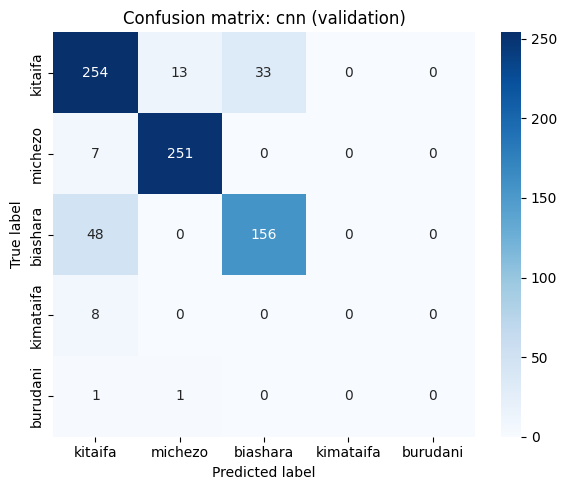

In [15]:
plots.plot_confusion_matrix(validation_ids, validation_probabilities, MODEL_NAME, "validation")

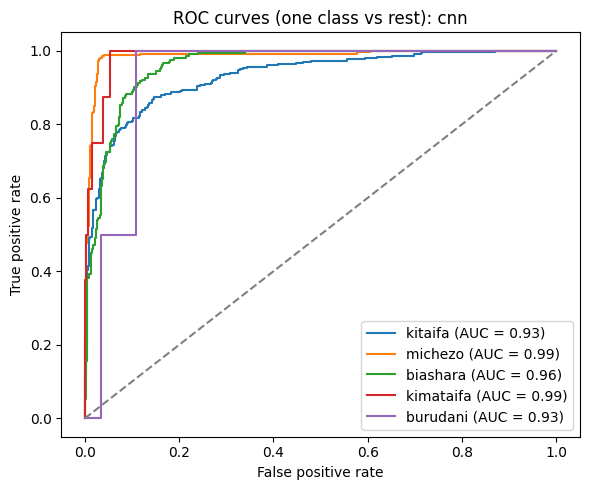

In [16]:
plots.plot_roc_curves(validation_ids, validation_probabilities, MODEL_NAME, "validation")

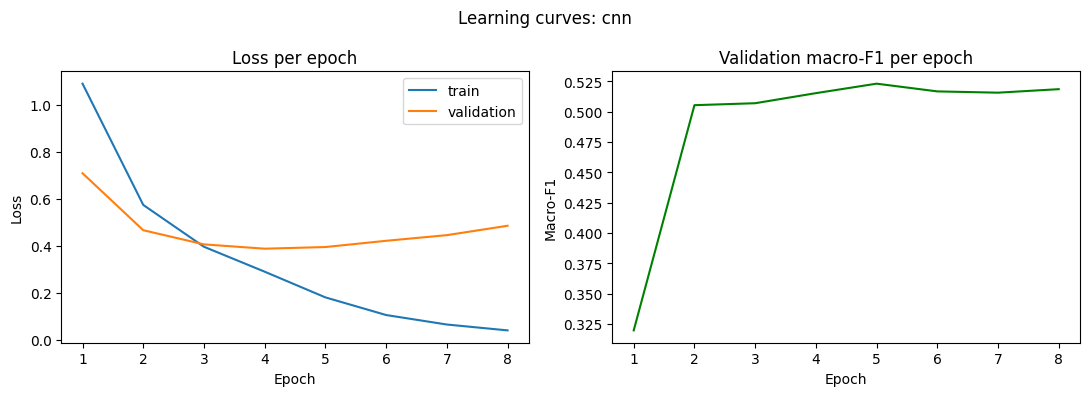

In [17]:
plots.plot_learning_curves(history, MODEL_NAME)

### 4c. Calibration (temperature scaling)

Neural networks are often overconfident, which hurts log loss (Guo et al., 2017). We fit one temperature on the validation logits, and log the scores **before and after** calibration so the report can show the difference.

In [18]:
from src import calibration

temperature = calibration.find_best_temperature(validation_logits, validation_ids)
print("Best temperature:", temperature)

calibrated_probabilities = calibration.softmax(validation_logits, temperature)
calibrated_scores = evaluation.compute_scores(validation_ids, calibrated_probabilities)

log_experiment(MEMBER, MODEL_NAME, experiment_name + "_calibrated", "validation",
               {**settings, "temperature": temperature}, calibrated_scores,
               "Same model after temperature scaling")
calibrated_scores

Best temperature: 1.10 (validation log loss 0.3856)
Best temperature: 1.1000000000000005
Logged experiment 'baseline_random_calibrated' to /content/nlp_language_technologies/results/experiment_logs/cnn.csv


{'accuracy': 0.8562,
 'log_loss': 0.3856,
 'macro_f1': 0.5151,
 'weighted_f1': 0.85,
 'f1_kitaifa': 0.822,
 'f1_michezo': 0.9598,
 'f1_biashara': 0.7939,
 'f1_kimataifa': 0.0,
 'f1_burudani': 0.0}

## 5. Final evaluation on the test set

The final model is trained once per seed in `FINAL_RUN_SEEDS`; each run is logged as `final_seed_<seed>` so the report can show the mean and spread. Each seed gets its own temperature, fitted on that run's validation logits.

Random seed set to 42
epoch 01 | train_loss 1.0905 | val_loss 0.7091 | val_macro_f1 0.3197
epoch 02 | train_loss 0.5742 | val_loss 0.4665 | val_macro_f1 0.5052
epoch 03 | train_loss 0.3961 | val_loss 0.4062 | val_macro_f1 0.5068
epoch 04 | train_loss 0.2899 | val_loss 0.3879 | val_macro_f1 0.5151
epoch 05 | train_loss 0.1806 | val_loss 0.3949 | val_macro_f1 0.5230
epoch 06 | train_loss 0.1055 | val_loss 0.4215 | val_macro_f1 0.5166
epoch 07 | train_loss 0.0650 | val_loss 0.4456 | val_macro_f1 0.5155
epoch 08 | train_loss 0.0401 | val_loss 0.4855 | val_macro_f1 0.5184
Early stopping at epoch 8
Best temperature: 1.10 (validation log loss 0.3856)
              precision    recall  f1-score   support

     kitaifa       0.83      0.84      0.84       300
     michezo       0.94      0.95      0.95       258
    biashara       0.82      0.82      0.82       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy          

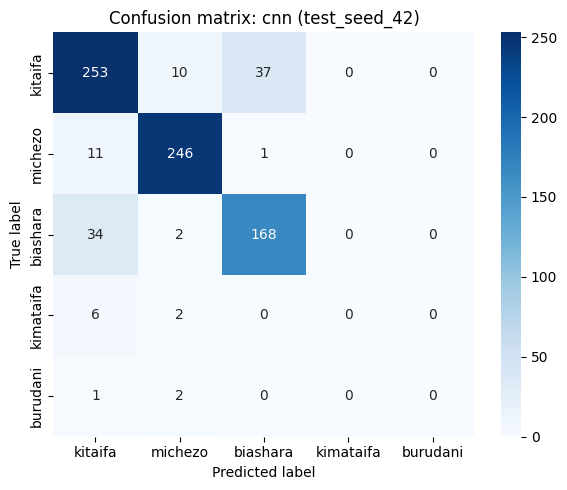

Random seed set to 7
epoch 01 | train_loss 1.0743 | val_loss 0.6928 | val_macro_f1 0.3903
epoch 02 | train_loss 0.5587 | val_loss 0.4791 | val_macro_f1 0.4930
epoch 03 | train_loss 0.4030 | val_loss 0.4267 | val_macro_f1 0.4993
epoch 04 | train_loss 0.2885 | val_loss 0.3900 | val_macro_f1 0.5172
epoch 05 | train_loss 0.1844 | val_loss 0.3957 | val_macro_f1 0.5126
epoch 06 | train_loss 0.1031 | val_loss 0.4262 | val_macro_f1 0.5203
epoch 07 | train_loss 0.0614 | val_loss 0.4632 | val_macro_f1 0.5267
epoch 08 | train_loss 0.0384 | val_loss 0.5085 | val_macro_f1 0.5137
Early stopping at epoch 8
Best temperature: 1.10 (validation log loss 0.3886)
              precision    recall  f1-score   support

     kitaifa       0.83      0.85      0.84       300
     michezo       0.94      0.95      0.94       258
    biashara       0.82      0.83      0.82       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy           

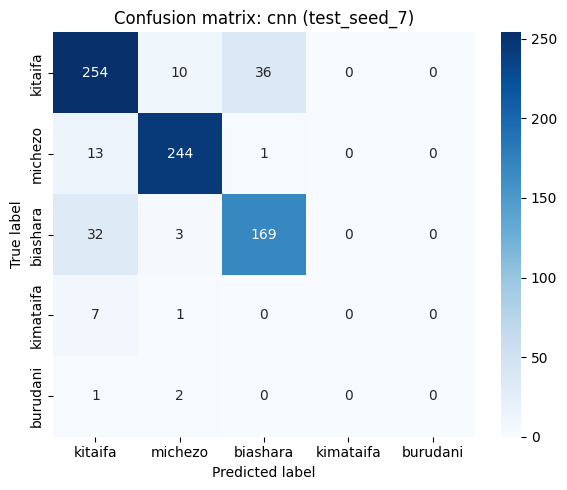

Random seed set to 2026
epoch 01 | train_loss 1.0846 | val_loss 0.7033 | val_macro_f1 0.4631
epoch 02 | train_loss 0.5609 | val_loss 0.4698 | val_macro_f1 0.4920
epoch 03 | train_loss 0.3930 | val_loss 0.4075 | val_macro_f1 0.5094
epoch 04 | train_loss 0.2888 | val_loss 0.3855 | val_macro_f1 0.5157
epoch 05 | train_loss 0.1773 | val_loss 0.3999 | val_macro_f1 0.5101
epoch 06 | train_loss 0.1101 | val_loss 0.4203 | val_macro_f1 0.5156
epoch 07 | train_loss 0.0662 | val_loss 0.4499 | val_macro_f1 0.5219
epoch 08 | train_loss 0.0377 | val_loss 0.4791 | val_macro_f1 0.5642
Early stopping at epoch 8
Best temperature: 1.05 (validation log loss 0.3844)
              precision    recall  f1-score   support

     kitaifa       0.81      0.84      0.82       300
     michezo       0.95      0.95      0.95       258
    biashara       0.80      0.81      0.80       204
   kimataifa       0.00      0.00      0.00         8
    burudani       0.00      0.00      0.00         3

    accuracy        

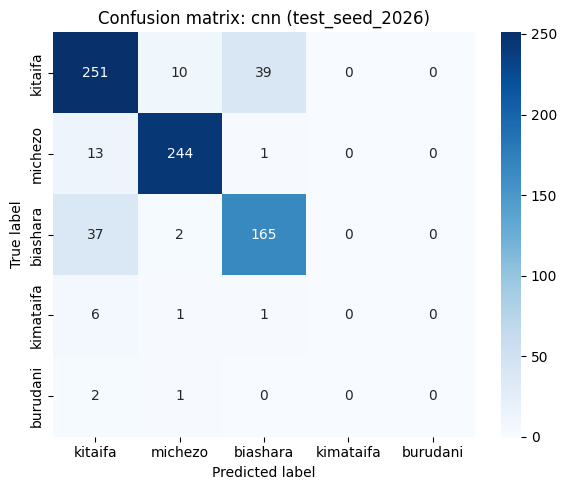

In [19]:
for seed in FINAL_RUN_SEEDS:
    final_model, final_history, val_logits = train_model(seed=seed)

    temperature = calibration.find_best_temperature(val_logits, validation_ids)
    test_logits = predict_logits(final_model, test["content"]).numpy()
    test_probabilities = calibration.softmax(test_logits, temperature)

    test_scores = evaluation.compute_scores(test_ids, test_probabilities)
    evaluation.print_classification_report(test_ids, test_probabilities)
    log_experiment(MEMBER, MODEL_NAME, f"final_seed_{seed}", "test",
                   {**settings, "temperature": temperature}, test_scores,
                   "Final model on the test set")

    plots.plot_confusion_matrix(test_ids, test_probabilities, MODEL_NAME, f"test_seed_{seed}")


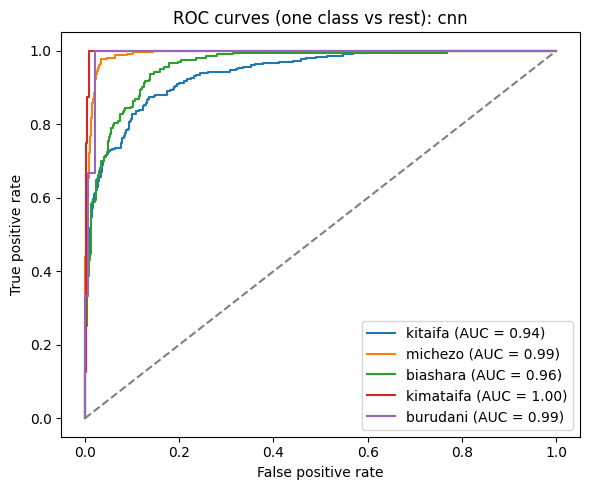

In [20]:
plots.plot_roc_curves(test_ids, test_probabilities, MODEL_NAME, "test")

In [21]:
evaluation.save_misclassified_examples(test, test_ids, test_probabilities, MODEL_NAME)

Saved 113 misclassified examples to /content/nlp_language_technologies/results/misclassified/cnn.csv


In [22]:
zindi_logits = predict_logits(final_model, zindi_test["content"]).numpy()
zindi_probabilities = calibration.softmax(zindi_logits, temperature)

evaluation.save_zindi_submission(zindi_test, zindi_probabilities, MODEL_NAME)

Saved Zindi submission to /content/nlp_language_technologies/results/submissions/cnn.csv


## 6. Saving the results results

files are downloaded and added to project's directory in `results/`.

In [23]:
if COLAB:
    from google.colab import files

    !zip -r results.zip results

    files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/experiment_logs/ (stored 0%)
  adding: results/experiment_logs/cnn.csv (deflated 76%)
  adding: results/submissions/ (stored 0%)
  adding: results/submissions/cnn.csv (deflated 49%)
  adding: results/misclassified/ (stored 0%)
  adding: results/misclassified/cnn.csv (deflated 66%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/eda/ (stored 0%)
  adding: results/figures/eda/article_length_histogram.png (deflated 10%)
  adding: results/figures/eda/article_length_by_class.png (deflated 13%)
  adding: results/figures/eda/class_distribution.png (deflated 13%)
  adding: results/figures/eda/zipf_plot.png (deflated 6%)
  adding: results/figures/eda/token_length_histogram.png (deflated 10%)
  adding: results/figures/cnn/ (stored 0%)
  adding: results/figures/cnn/confusion_matrix_test_seed_42.png (deflated 12%)
  adding: results/figures/cnn/confusion_matrix_validation.png (deflated 12%)
  adding: results/figures/cnn/confusion_mat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>